# Load validation data

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [9]:
df_gt = pd.read_csv("data_info/CoresGT_val.csv")
df_gt

,corename,Sum of 0<.L.<=1.000000,Sum of 1.0000000<.L.<=2.0000000,Sum of 2.0000000<.L.<=3.0000000,Sum of 3.0000000<.L.<=4.0000000,Sum of .L.>4.0000000,L00,L10,L20,L30,L40
0,C1216,889.1,141.6,9.1,0.5,0.0,1040.3,151.2,9.6,0.5,0.0
1,C2609,2993.9,318.2,75.0,26.3,12.3,3425.7,431.8,113.6,38.6,12.3
2,C2803,462.8,138.6,129.2,14.2,0.0,744.8,282.0,143.4,14.2,0.0
3,C5608,2014.3,707.6,207.8,19.5,0.7,2949.9,935.6,228.0,20.2,0.7
4,S1510,1329.9,423.7,67.7,8.9,2.3,1832.5,502.6,78.9,11.2,2.3
5,S1919,4650.3,961.8,212.7,16.1,0.8,5841.7,1191.4,229.6,16.9,0.8
6,S2307,1233.1,236.0,8.9,0.2,0.0,1478.2,245.1,9.1,0.2,0.0
7,S2403,2091.2,660.3,167.9,15.1,1.3,2935.8,844.6,184.3,16.4,1.3
8,S3117,582.4,532.4,152.9,9.4,0.0,1277.1,694.7,162.3,9.4,0.0
9,S3603,811.5,328.5,125.8,2.0,0.0,1267.8,456.3,127.8,2.0,0.0


In [10]:
model_name = "unetr"
df_pred = pd.read_csv(f"data_info/prediction_{model_name}_val.csv")
df_pred

,soil_core,total_images,Root Length Diameter Range 1 (px),Root Length Diameter Range 2 (px),Root Length Diameter Range 3 (px),Root Length Diameter Range 4 (px),Root Length Diameter Range 5 (px),L00,L10,L20,L30,L40
0,C1216,108,0,18948.44335,4073.067602,62.313708,0,23083.82466,23083.82466,4135.381310,62.313708,0
1,C2003,94,0,13594.74033,4097.710171,49.727922,0,17742.17842,17742.17842,4147.438093,49.727922,0
2,C2609,106,0,20418.49213,7156.631452,84.284271,0,27659.40785,27659.40785,7240.915724,84.284271,0
3,C2803,108,0,15114.44090,2351.787156,13.414214,0,17479.64227,17479.64227,2365.201369,13.414214,0
4,C5608,105,0,17656.95685,3558.715221,41.485281,0,21257.15735,21257.15735,3600.200503,41.485281,0
5,C6405,109,0,15632.01450,2745.343505,13.828427,0,18391.18643,18391.18643,2759.171932,13.828427,0
6,S1510,104,0,16174.28571,5918.536865,86.556349,0,22179.37892,22179.37892,6005.093214,86.556349,0
7,S1919,105,0,24905.43065,9912.354683,138.526912,0,34956.31225,34956.31225,10050.881590,138.526912,0
8,S2307,102,0,18334.52452,9762.913991,154.769553,0,28252.20807,28252.20807,9917.683543,154.769553,0
9,S2403,101,0,23676.00511,8700.059085,274.379726,0,32650.44392,32650.44392,8974.438810,274.379726,0


In [11]:
# Keep only the cores that are in both datasets
df_gt = df_gt[df_gt["corename"].isin(df_pred["soil_core"])].reset_index(drop=True)
df_pred = df_pred[df_pred["soil_core"].isin(df_gt["corename"])].reset_index(drop=True)


c:\Users\JF\.conda\envs\soilcores\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\JF\.conda\envs\soilcores\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Text(0.5, 1.0, 'Best correlation: 0.78')

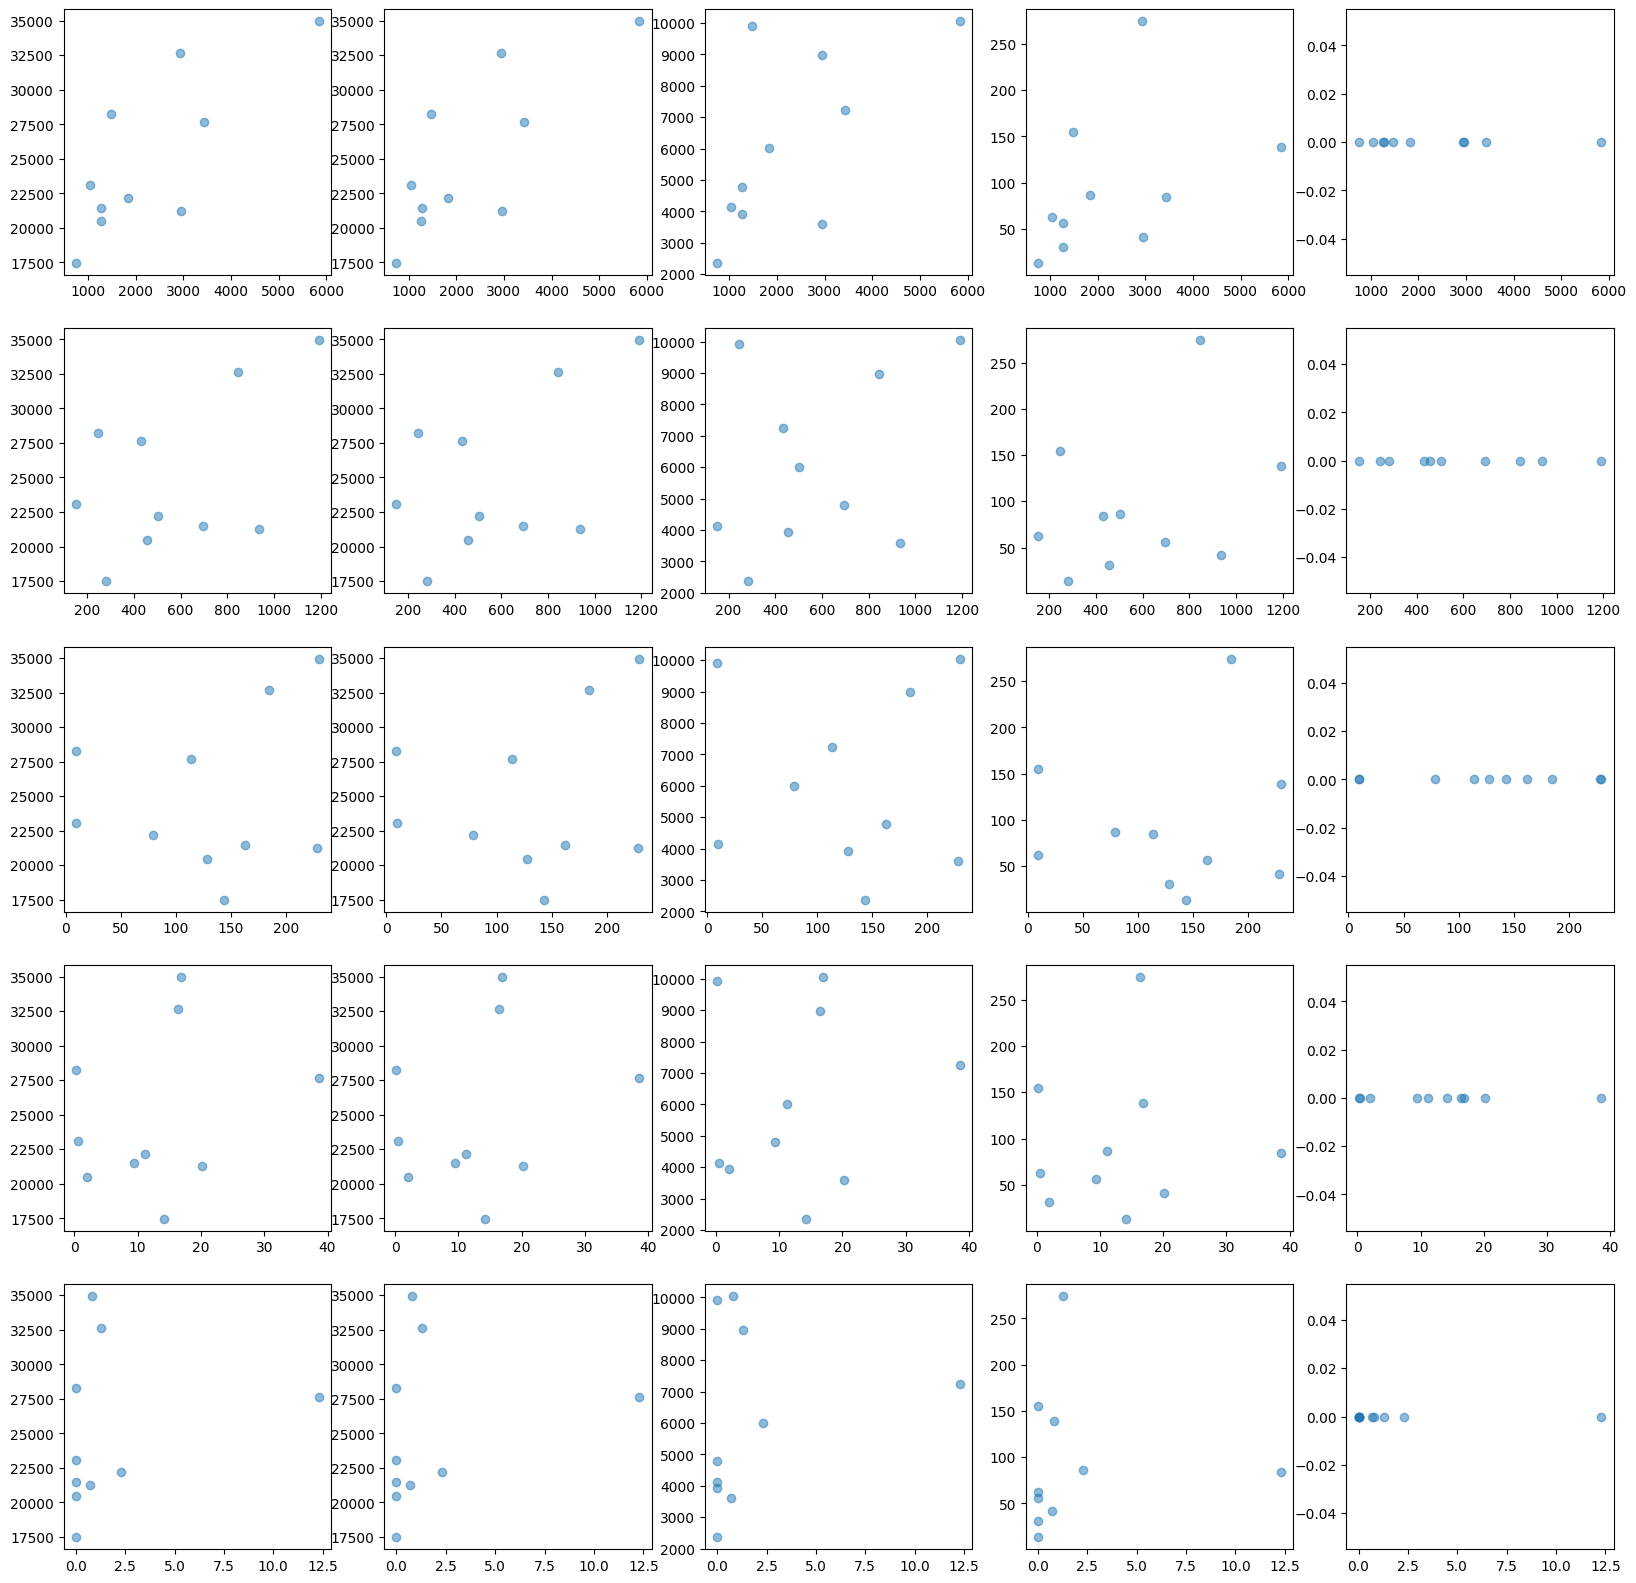

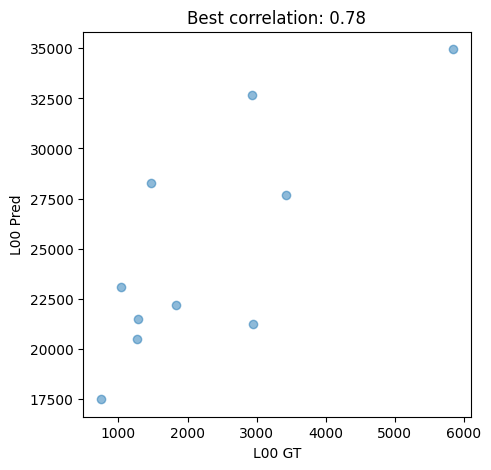

In [12]:
lfeat = ['L00', 'L10', 'L20', 'L30', 'L40']

plt.figure(figsize=(20, 20))

corrmat = np.zeros((len(lfeat), len(lfeat)))
for i, xfeat in enumerate(lfeat):
    for j, yfeat in enumerate(lfeat):
        plt.subplot(len(lfeat), len(lfeat), i*len(lfeat) + j + 1)
        x = df_gt[xfeat].values
        y = df_pred[yfeat].values
        corrmat[i, j] = np.corrcoef(x, y)[0, 1]
        plt.scatter(x, y, alpha=0.5)
        # plt.xlabel("WinRHIZO")
        # plt.ylabel("U-Net")
        # plt.title("Root length (cm) prediction")

corrmat[np.isnan(corrmat)] = 0

# Best correlation
plt.figure(figsize=(5, 5))
ix, iy = np.unravel_index(np.argmax(corrmat), corrmat.shape)
xfeat, yfeat = lfeat[ix], lfeat[iy]
plt.scatter(df_gt[xfeat].values, df_pred[yfeat].values, alpha=0.5)
plt.xlabel(f"{xfeat} GT")
plt.ylabel(f"{yfeat} Pred")
plt.title(f"Best correlation: {corrmat[ix, iy]:.2f}")

Text(0.5, 1.0, 'Correlation: 0.78')

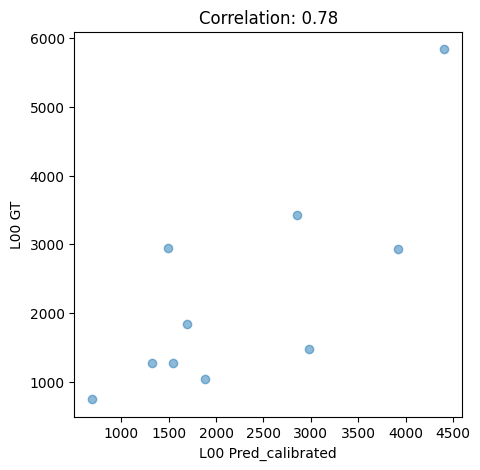

In [6]:
# Calibrating the prediction yfeat to the GT scale xfeat

from scipy import stats

x = df_gt[xfeat].values   # GT
y = df_pred[yfeat].values         # predictions

# Regress: GT = slope * prediction + intercept  (i.e. x = slope*y + intercept)
slope, intercept, r, p, se = stats.linregress(y, x)

y_calibrated = slope * y + intercept

plt.figure(figsize=(5, 5))
plt.scatter(y_calibrated, x, alpha=0.5)
plt.xlabel(f"{yfeat} Pred_calibrated")
plt.ylabel(f"{xfeat} GT")
plt.title(f"Correlation: {r:.2f}")


In [7]:
import json

# Save calibration parameters
calibration_params = {
    "slope": slope,
    "intercept": intercept,
    "r": r,
    "p": p,
    "se": se,
    "xfeat": xfeat,
    "yfeat": yfeat
}

# Save calibration parameters to a JSON file
with open(f"data_info/calibration_params_{model_name}.json", "w") as f:
    json.dump(calibration_params, f)
